In [4]:
!pip install kagglehub
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

In [5]:
import pandas as pd

# load
ayur = pd.read_csv("AyurGenixAI_Dataset.csv")
prakriti = pd.read_csv("Prakriti_Tridosha_Dataset.csv")

# rename for consistency
ayur.columns = (
    ayur.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
)
ayur = ayur.rename(columns={'constitution_prakriti': 'prakriti_type'})

prakriti.columns = (
    prakriti.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

In [6]:
# group prakriti dataset by dosha and aggregates traits using mode, which selects the most common value per dosha.
prakriti_summary = (
    prakriti
    .groupby('dosha')
    .agg({
        'body_size': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
        'complexion': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
        'metabolism_type': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
        'climate_preference': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
        'stress_levels': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
        'sleep_patterns': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
        'dietary_habits': lambda x: x.mode().iloc[0] if not x.mode().empty else None
    })
    .reset_index()
    .rename(columns={'dosha': 'prakriti_type'})
)

# merge with AyurGenixAI
merged = pd.merge(
    ayur,
    prakriti_summary,
    on='prakriti_type',
    how='left'
)

print(prakriti.columns.tolist())
print(merged[['prakriti_type']].head())
print(merged.columns.tolist())

['body_size', 'body_weight', 'height', 'bone_structure', 'complexion', 'general_feel_of_skin', 'texture_of_skin', 'hair_color', 'appearance_of_hair', 'shape_of_face', 'eyes', 'eyelashes', 'blinking_of_eyes', 'cheeks', 'nose', 'teeth_and_gums', 'lips', 'nails', 'appetite', 'liking_tastes', 'dosha', 'metabolism_type', 'climate_preference', 'stress_levels', 'sleep_patterns', 'dietary_habits', 'physical_activity_level', 'water_intake', 'digestion_quality', 'skin_sensitivity']
  prakriti_type
0    Vata-Kapha
1         Kapha
2         Pitta
3    Pitta-Vata
4          Vata
['disease', 'hindi_name', 'marathi_name', 'symptoms', 'diagnosis_&_tests', 'symptom_severity', 'duration_of_treatment', 'medical_history', 'current_medications', 'risk_factors', 'environmental_factors', 'sleep_patterns_x', 'stress_levels_x', 'physical_activity_levels', 'family_history', 'dietary_habits_x', 'allergies_(food_env)', 'seasonal_variation', 'age_group', 'gender', 'occupation_and_lifestyle', 'cultural_preferences'

In [7]:
# Convert ordinal/numeric-like strings to numbers.
severity_map = {
    'mild': 1,
    'mild to moderate': 2,
    'moderate': 3,
    'moderate to high': 4,
    'moderate to severe': 4,
    'high': 5,
    'severe': 6
}
merged['symptom_severity_num'] = merged['symptom_severity'].str.lower().map(severity_map)

# Convert duration_of_treatment to numeric
merged['duration_of_treatment_num'] = pd.to_numeric(merged['duration_of_treatment'], errors='coerce')
merged['duration_of_treatment_num'] = merged['duration_of_treatment_num'].fillna(merged['duration_of_treatment_num'].median())

# Similarly for stress_levels_x if needed
stress_map = {'low': 1, 'medium': 2, 'high': 3}
merged['stress_levels_x_num'] = merged['stress_levels_x'].str.lower().map(stress_map)
merged['stress_levels_x_num'] = merged['stress_levels_x_num'].fillna(2)  # fill missing with medium

# Update your numeric columns for the preprocessor
num_cols = ['symptom_severity_num', 'stress_levels_x_num', 'duration_of_treatment_num']

# Update categorical columns
cat_cols = [
    'doshas', 'prakriti_type', 'sleep_patterns_x',
    'dietary_habits_x', 'body_size', 'metabolism_type'
]

# Define X using numeric & categorical versions
feature_cols_processed = num_cols + cat_cols

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = merged[feature_cols_processed]
y = merged['symptom_severity'].map(lambda x: 1 if x.lower() in ['mild', 'mild to moderate', 'moderate'] else 0)

# Pipeline / preprocessor
num_idx = [X.columns.get_loc(c) for c in num_cols]
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='constant', fill_value=0), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

# Transform features
X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:572: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(


In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)

# Feature importance
importances = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out(),
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Training score:", rf.score(X_train, y_train))
print("Test score:", rf.score(X_test, y_test))

print("Top 5 features:", importances.head())

Training score: 0.9915730337078652
Test score: 0.9444444444444444
Top 5 features:                                                feature  importance
0                            num__symptom_severity_num    0.441746
197            cat__dietary_habits_x_Spicy, Oily foods    0.036904
35                 cat__dietary_habits_x_Balanced diet    0.029338
46     cat__dietary_habits_x_Balanced, High-fluid diet    0.028311
36   cat__dietary_habits_x_Balanced diet, High-protein    0.022388


In [10]:
print(y_train.value_counts())
print(y_test.value_counts())

symptom_severity
0    323
1     33
Name: count, dtype: int64
symptom_severity
0    82
1     8
Name: count, dtype: int64


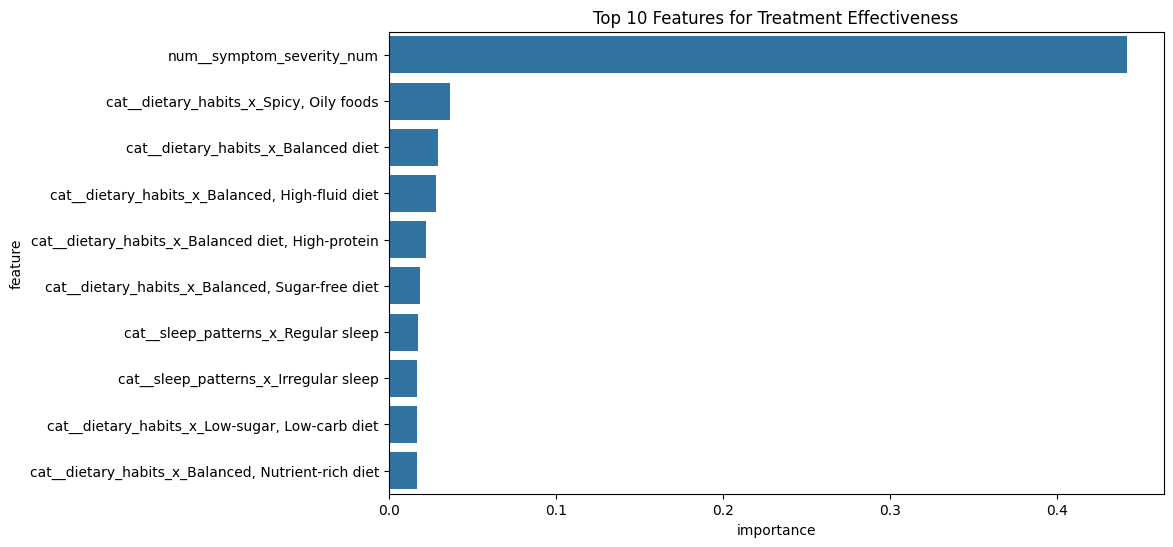

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = importances.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=top_features)
plt.title('Top 10 Features for Treatment Effectiveness')
plt.show()

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_score

# Test set predictions
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]  # probability of positive class

# Classification metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", roc_auc)

# 5-fold Cross-Validation (F1)
cv_scores = cross_val_score(rf, X_processed, y, cv=5, scoring='f1')
print("5-Fold CV F1: {:.2f} ± {:.2f}".format(cv_scores.mean(), cv_scores.std()))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        82
           1       1.00      0.38      0.55         8

    accuracy                           0.94        90
   macro avg       0.97      0.69      0.76        90
weighted avg       0.95      0.94      0.93        90

ROC-AUC: 0.9984756097560977
5-Fold CV F1: 0.68 ± 0.20


In [13]:
from sklearn.model_selection import GridSearchCV

# Grid of hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearch with 5-fold CV, optimizing F1
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("=== GridSearchCV Results ===")
print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

=== GridSearchCV Results ===
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.8251282051282051


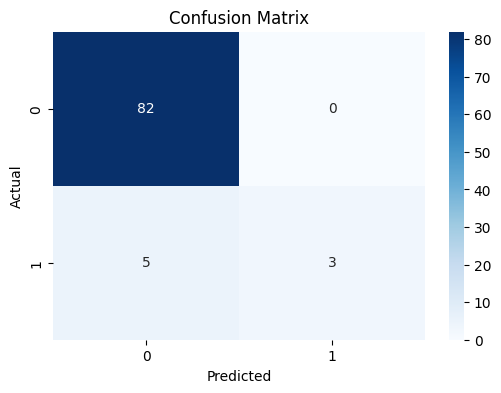

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title('Confusion Matrix')
plt.show()

In [18]:
def predict_herbs(patient_data, df_merged=merged):
    """
    Demo function for new patient.
    Input: patient_data -> dict of features
    Output: probability of effective treatment & top 3 herbs
    """
    import pandas as pd

    # Convert dict to single-row DataFrame
    patient_df = pd.DataFrame([patient_data])

    # Force numeric columns to float
    numeric_cols = ['symptom_severity_num', 'stress_levels_x_num', 'duration_of_treatment_num']
    patient_df[numeric_cols] = patient_df[numeric_cols].astype(float)

    # Transform features using preprocessor
    patient_features = preprocessor.transform(patient_df)

    # Predict probability of effective treatment
    prob = grid_search.predict_proba(patient_features)[0, 1]

    # Example: choose herbs for patients with "Good" prognosis
    herbs = df_merged[
    (df_merged['prakriti_type'] == patient_data['prakriti_type']) &
    (df_merged['doshas'] == patient_data['doshas'])
]['ayurvedic_herbs'].head(3)

    return f"Effectiveness: {prob:.2f} | Top Herbs: {herbs.tolist()}"

In [19]:
new_patient = {
    'symptom_severity_num': 2,
    'stress_levels_x_num': 2,
    'duration_of_treatment_num': 30,
    'doshas': 'Vata',
    'prakriti_type': 'Vata',
    'sleep_patterns_x': 'Regular',
    'dietary_habits_x': 'Balanced',
    'body_size': 'Medium',
    'metabolism_type': 'Normal',
    'complications': None
}

print(predict_herbs(new_patient))

Effectiveness: 0.69 | Top Herbs: ['Triphala, Isabgol', 'Ashwagandha, Brahmi', 'None specific']


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
